### Home Credit EDA
#### Darren Black
#### IS 6812
#### 9/29/2024

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


Many individuals with limited or no credit history struggle to obtain loans, often falling prey to unreliable lenders. Home Credit Group aims to broaden financial inclusion by providing safe loans to these individuals. This project will focus on improving Home Credit’s loan predictions of client’s repayment abilities. Effectively allowing them to reach more people without the risk of sky rocketing default rates. In this notebook we will be looking over the data and clarify what aspects of it can be used in our model to detect trustworthy borrows. We will also be looking at what area might need to be cleaned up or looked into more.

# Application Train|Test Analysis

In [61]:
# loading the data
application_train = pd.read_csv(r"C:\Users\darre\Downloads\home-credit-default-risk\application_train.csv")
application_test = pd.read_csv(r"C:\Users\darre\Downloads\home-credit-default-risk\application_test.csv")


What is the shape of the testing and training sets?

In [62]:
# looking that the number of rows and columns in train
print(application_train.shape[1])
print(application_train.shape[0])

122
307511


In [63]:
# looking that the number of rows and columns in test
print(application_test.shape[1])
print(application_test.shape[0])

121
48744


What is the data type of each column?

In [64]:
print(application_train.info())
print(application_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB
None


What are means, std, max, and min for each column?

In [65]:
#getting an overview of the training set
application_train.describe().apply(lambda x: x.apply('{0:.2f}'.format))

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.00,307511.00,307511.00,307511.00,307511.00,307499.00,307233.00,307511.00,307511.00,307511.00,...,307511.00,307511.00,307511.00,307511.00,265992.00,265992.00,265992.00,265992.00,265992.00,265992.00
mean,278180.52,0.08,0.42,168797.92,599026.00,27108.57,538396.21,0.02,-16037.00,63815.05,...,0.01,0.00,0.00,0.00,0.01,0.01,0.03,0.27,0.27,1.90
std,102790.18,0.27,0.72,237123.15,402490.78,14493.74,369446.46,0.01,4363.99,141275.77,...,0.09,0.02,0.02,0.02,0.08,0.11,0.20,0.92,0.79,1.87
min,100002.00,0.00,0.00,25650.00,45000.00,1615.50,40500.00,0.00,-25229.00,-17912.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189145.50,0.00,0.00,112500.00,270000.00,16524.00,238500.00,0.01,-19682.00,-2760.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,278202.00,0.00,0.00,147150.00,513531.00,24903.00,450000.00,0.02,-15750.00,-1213.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
75%,367142.50,0.00,1.00,202500.00,808650.00,34596.00,679500.00,0.03,-12413.00,-289.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00
max,456255.00,1.00,19.00,117000000.00,4050000.00,258025.50,4050000.00,0.07,-7489.00,365243.00,...,1.00,1.00,1.00,1.00,4.00,9.00,8.00,27.00,261.00,25.00


In [66]:
#getting an overview of the testing set
application_test.describe().apply(lambda x: x.apply('{0:.2f}'.format))

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.00,48744.00,48744.00,48744.00,48720.00,48744.00,48744.00,48744.00,48744.00,48744.00,...,48744.00,48744.00,48744.00,48744.00,42695.00,42695.00,42695.00,42695.00,42695.00,42695.00
mean,277796.68,0.40,178431.81,516740.44,29426.24,462618.84,0.02,-16068.08,67485.37,-4967.65,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.55,1.98
std,103169.55,0.71,101522.59,365397.00,16016.37,336710.22,0.01,4325.90,144348.51,3552.61,...,0.04,0.00,0.00,0.00,0.05,0.05,0.05,0.11,0.69,1.84
min,100001.00,0.00,26941.50,45000.00,2295.00,45000.00,0.00,-25195.00,-17463.00,-23722.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,188557.75,0.00,112500.00,260640.00,17973.00,225000.00,0.01,-19637.00,-2910.00,-7459.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,277549.00,0.00,157500.00,450000.00,26199.00,396000.00,0.02,-15785.00,-1293.00,-4490.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
75%,367555.50,1.00,225000.00,675000.00,37390.50,630000.00,0.03,-12496.00,-296.00,-1901.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
max,456250.00,20.00,4410000.00,2245500.00,180576.00,2245500.00,0.07,-7338.00,365243.00,0.00,...,1.00,0.00,0.00,0.00,2.00,2.00,2.00,6.00,7.00,17.00


How is the target variable balanced in each dataset?

In [67]:
#looking at the target varibale ratio
print(application_train['TARGET'].value_counts())
print(application_train['TARGET'].mean())

TARGET
0    282686
1     24825
Name: count, dtype: int64
0.08072881945686496


This is clearly unbalanced with a majority classifer being 92%. Only 8% percent of people had payment difficulties. This will be a vital number for us to look at and measure the accuracy of our model against.

How are all the variable related/correlated to our target?

In [68]:
# Correlation matrix with respect to target variable
application_train_numeric = application_train.select_dtypes(include=[float,int])
corr_matrix = application_train_numeric.corr()
print(corr_matrix['TARGET'].sort_values(ascending=False).head(10))
print(corr_matrix['TARGET'].sort_values(ascending=False).tail(10))

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64


Its important to look at the top most positively and negatively correlated field because those are one that will most liekly be driving the prediciton of our model. If we can we should look into preserving these fields.

What does a random forest classifer believe are the most important fields to our Target?

In [69]:
# encoding the categorical field so that we can get proper view of their importance.
label_encoder = LabelEncoder()
application_train['NAME_EDUCATION_TYPE'] = label_encoder.fit_transform(application_train['NAME_EDUCATION_TYPE'])
application_train['WEEKDAY_APPR_PROCESS_START'] = label_encoder.fit_transform(application_train['WEEKDAY_APPR_PROCESS_START']) 
df_encoded = pd.get_dummies(application_train, columns=['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',
                                                        'NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE',
                                                        'ORGANIZATION_TYPE','FONDKAPREMONT_MODE','HOUSETYPE_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE'], drop_first=True)
len(df_encoded.columns)

222

In [70]:
# running the random forest classifer
model = RandomForestClassifier()
X = df_encoded.drop('TARGET', axis=1)
y = df_encoded['TARGET']
model.fit(X, y)

importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(25))

                        Feature  Importance
31                 EXT_SOURCE_2    0.050482
32                 EXT_SOURCE_3    0.048329
8                    DAYS_BIRTH    0.033051
11              DAYS_ID_PUBLISH    0.032404
10            DAYS_REGISTRATION    0.031857
0                    SK_ID_CURR    0.031031
4                   AMT_ANNUITY    0.029622
80       DAYS_LAST_PHONE_CHANGE    0.028938
9                 DAYS_EMPLOYED    0.028624
3                    AMT_CREDIT    0.027843
30                 EXT_SOURCE_1    0.026133
2              AMT_INCOME_TOTAL    0.025036
5               AMT_GOODS_PRICE    0.024666
7    REGION_POPULATION_RELATIVE    0.024628
23      HOUR_APPR_PROCESS_START    0.022380
106  AMT_REQ_CREDIT_BUREAU_YEAR    0.015971
22   WEEKDAY_APPR_PROCESS_START    0.015816
12                  OWN_CAR_AGE    0.013285
78     OBS_60_CNT_SOCIAL_CIRCLE    0.013183
76     OBS_30_CNT_SOCIAL_CIRCLE    0.013079
19              CNT_FAM_MEMBERS    0.010196
75               TOTALAREA_MODE 

Here we get a better look at our most important fields. Interestingly enough they are almost identical to the ones we that had the highest correlation to the target variable. Overall this is a good sign. We can also be confident that these are the most important fields because they include categorical as well as numerical fields. 

How many missing values does each dataset have?

In [71]:
# looking at NAs in train
application_train.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

<Axes: >

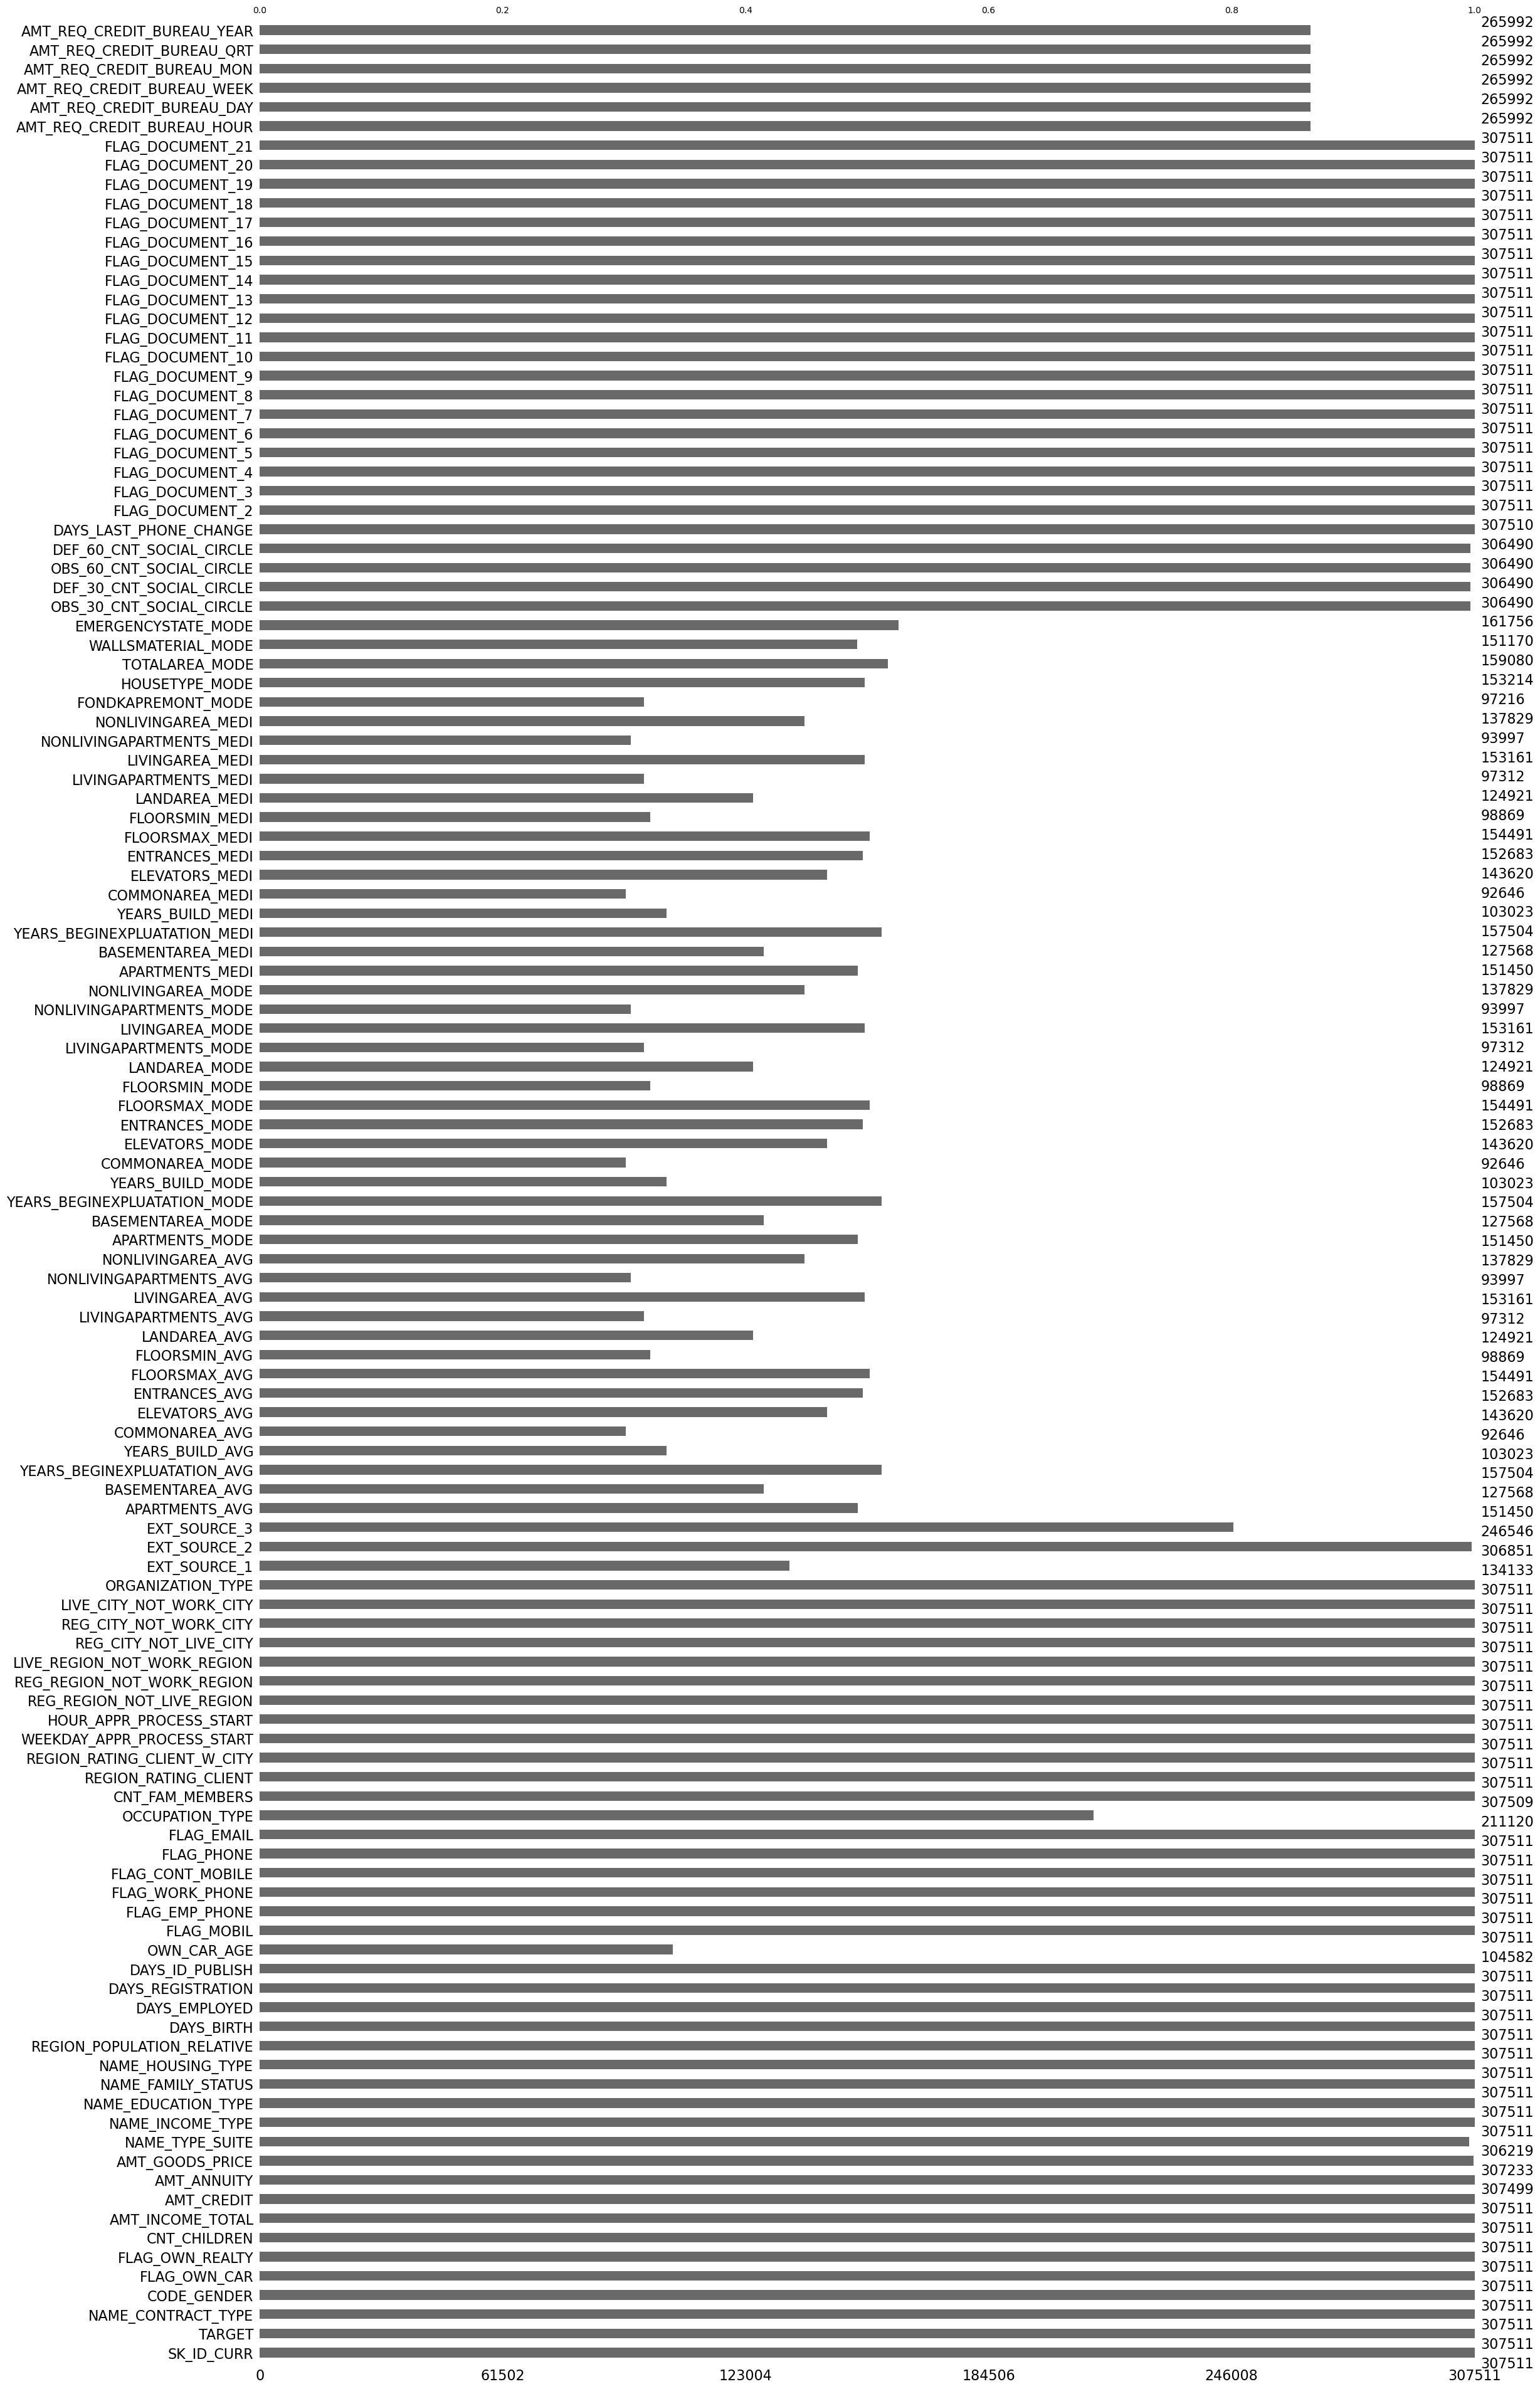

In [72]:
msno.bar(application_train)

This graph is vital because it give us a look into what fields have the most missing values and their proportion to non-missing values. Unfortuantely, there are a number of columns that have more thamn 50 percent missing values. Even more importantly, some of them seem to highly correlated to the our target. A good example of this is LIVINGAREA_AVG. This brings up the question of how to handle these missing values. I beleive an easy method to handle a large portion of them would be to eliminate a lare portion of the fields that are highly correlated to eachother. Coming back to the LIVINGAREA_AVG, it has two other similar fields, LIVINGAREA_MEDI and LIVINGAREA_MODE. These fields are very similar to the average. While they won't be exactly the same they are very correlated to eachother. So we could easily delete these and just keep one. This would go a long way in helping us deal with missing values. 

In [73]:
# looking at NAs in test
application_test.isna().sum()


SK_ID_CURR                       0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
FLAG_OWN_REALTY                  0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     6049
AMT_REQ_CREDIT_BUREAU_WEEK    6049
AMT_REQ_CREDIT_BUREAU_MON     6049
AMT_REQ_CREDIT_BUREAU_QRT     6049
AMT_REQ_CREDIT_BUREAU_YEAR    6049
Length: 121, dtype: int64

Here we can see that the test dataset suffers from the same missing values issues as the training set. Hopefully if we use the same methods on one of them it will fix the other as well.

# Bureau Analysis

In [74]:
#reading in bureau data
bureau = pd.read_csv(r"C:\Users\darre\Downloads\home-credit-default-risk\bureau.csv")

In [75]:
# looking that the number of rows and columns
print(bureau.shape[1])
print(bureau.shape[0])

17
1716428


In [76]:
bureau.describe().apply(lambda x: x.apply('{0:.2f}'.format))

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1716428.00,1716428.00,1716428.00,1716428.00,1610875.00,1082775.00,591940.00,1716428.00,1716415.00,1458759.00,1124648.00,1716428.00,1716428.00,489637.00
mean,278214.93,5924434.49,-1142.11,0.82,510.52,-1017.44,3825.42,0.01,354994.59,137085.12,6229.51,37.91,-593.75,15712.76
std,102938.56,532265.73,795.16,36.54,4994.22,714.01,206031.61,0.10,1149811.34,677401.13,45032.03,5937.65,720.75,325826.95
min,100001.00,5000000.00,-2922.00,0.00,-42060.00,-42023.00,0.00,0.00,0.00,-4705600.32,-586406.11,0.00,-41947.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1138.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50


The overall all view of this dataset has some interesting aspects to it. Mainly, that of getting a feels for credit amounts and over due credit. As we can see above, most of the averages look pretty resonable. However, we can can see some obvious outlyers that exist in the data. For example if we look at the "amt_credit_max_overdue" the largest value in this column is 115,987,185. This is a very large amount of money that is owed and depending on the individuals income, probably won't get payed back. If we continue comparing different field means and maxs, we can see a number of them suffer from outliers, many of which could be indicates that a person is not trust worthy to lend to. 

In [77]:
#creating a function to count the number of outliers in a dataframe
def count_outliers(df):
    outliers_count = {}
    
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            # Calculating the Quntile ranges
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Count outliers
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
            outliers_count[column] = len(outliers)
        else:
            outliers_count[column] = 'Non-numeric column'
    
    return outliers_count


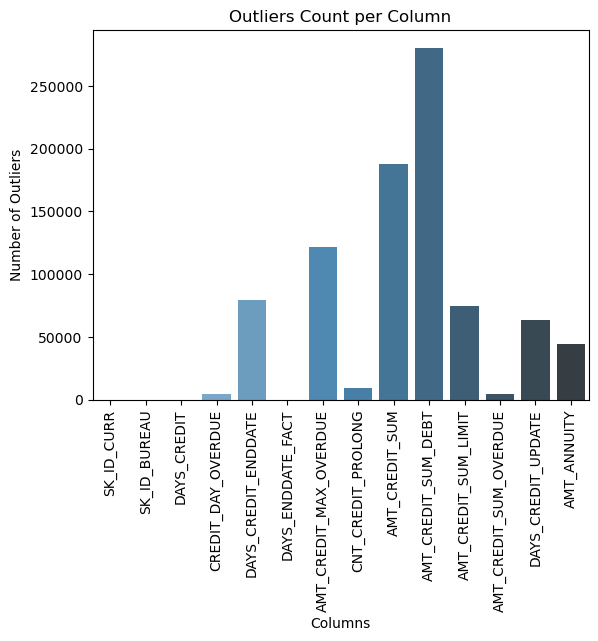

In [78]:
# using the outlier function
outliers = count_outliers(bureau)
outliers_df = pd.DataFrame(list(outliers.items()), columns=['Column', 'Outliers'])
outliers_df = outliers_df.loc[outliers_df['Outliers'] != 'Non-numeric column']
outliers_df['Outliers'] = outliers_df['Outliers'].astype(int)

outliers_plt = sns.barplot(x='Column', y='Outliers', data=outliers_df, palette='Blues_d')

# Add labels and title
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.ylabel('Number of Outliers')
plt.title('Outliers Count per Column')
    
# Show the plot
plt.show()

Unfortuantely, there are a lot of outliers to handle. For example, 'AMT_CREDIT_SUM_DEBT' has 280,455. This could require us to remove them or mitigate the problematic columns in some way. On the bright side, this entire dataset will have to be aggregated on the SK_ID_CURR level in order to attach it to our testing and training sets. This might give us a chance to mitigate the outliers. Plus, as mention in the outline for this project outliers don't always have to be removed. I do worry though at the quantity that is appearing in this dataset though.

In [79]:
#looking at missing values for each column
bureau.isna().sum()

SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_OVERDUE          0
CREDIT_TYPE                     0
DAYS_CREDIT_UPDATE              0
AMT_ANNUITY               1226791
dtype: int64

Moving on to null/NA/missing values, we can see that we have quite a few columns in this dataset that have a lot of missing values. The largest of which is 'AMT_ANNUITY'. But what is the proportion of missing values to non-missing values?

<Axes: >

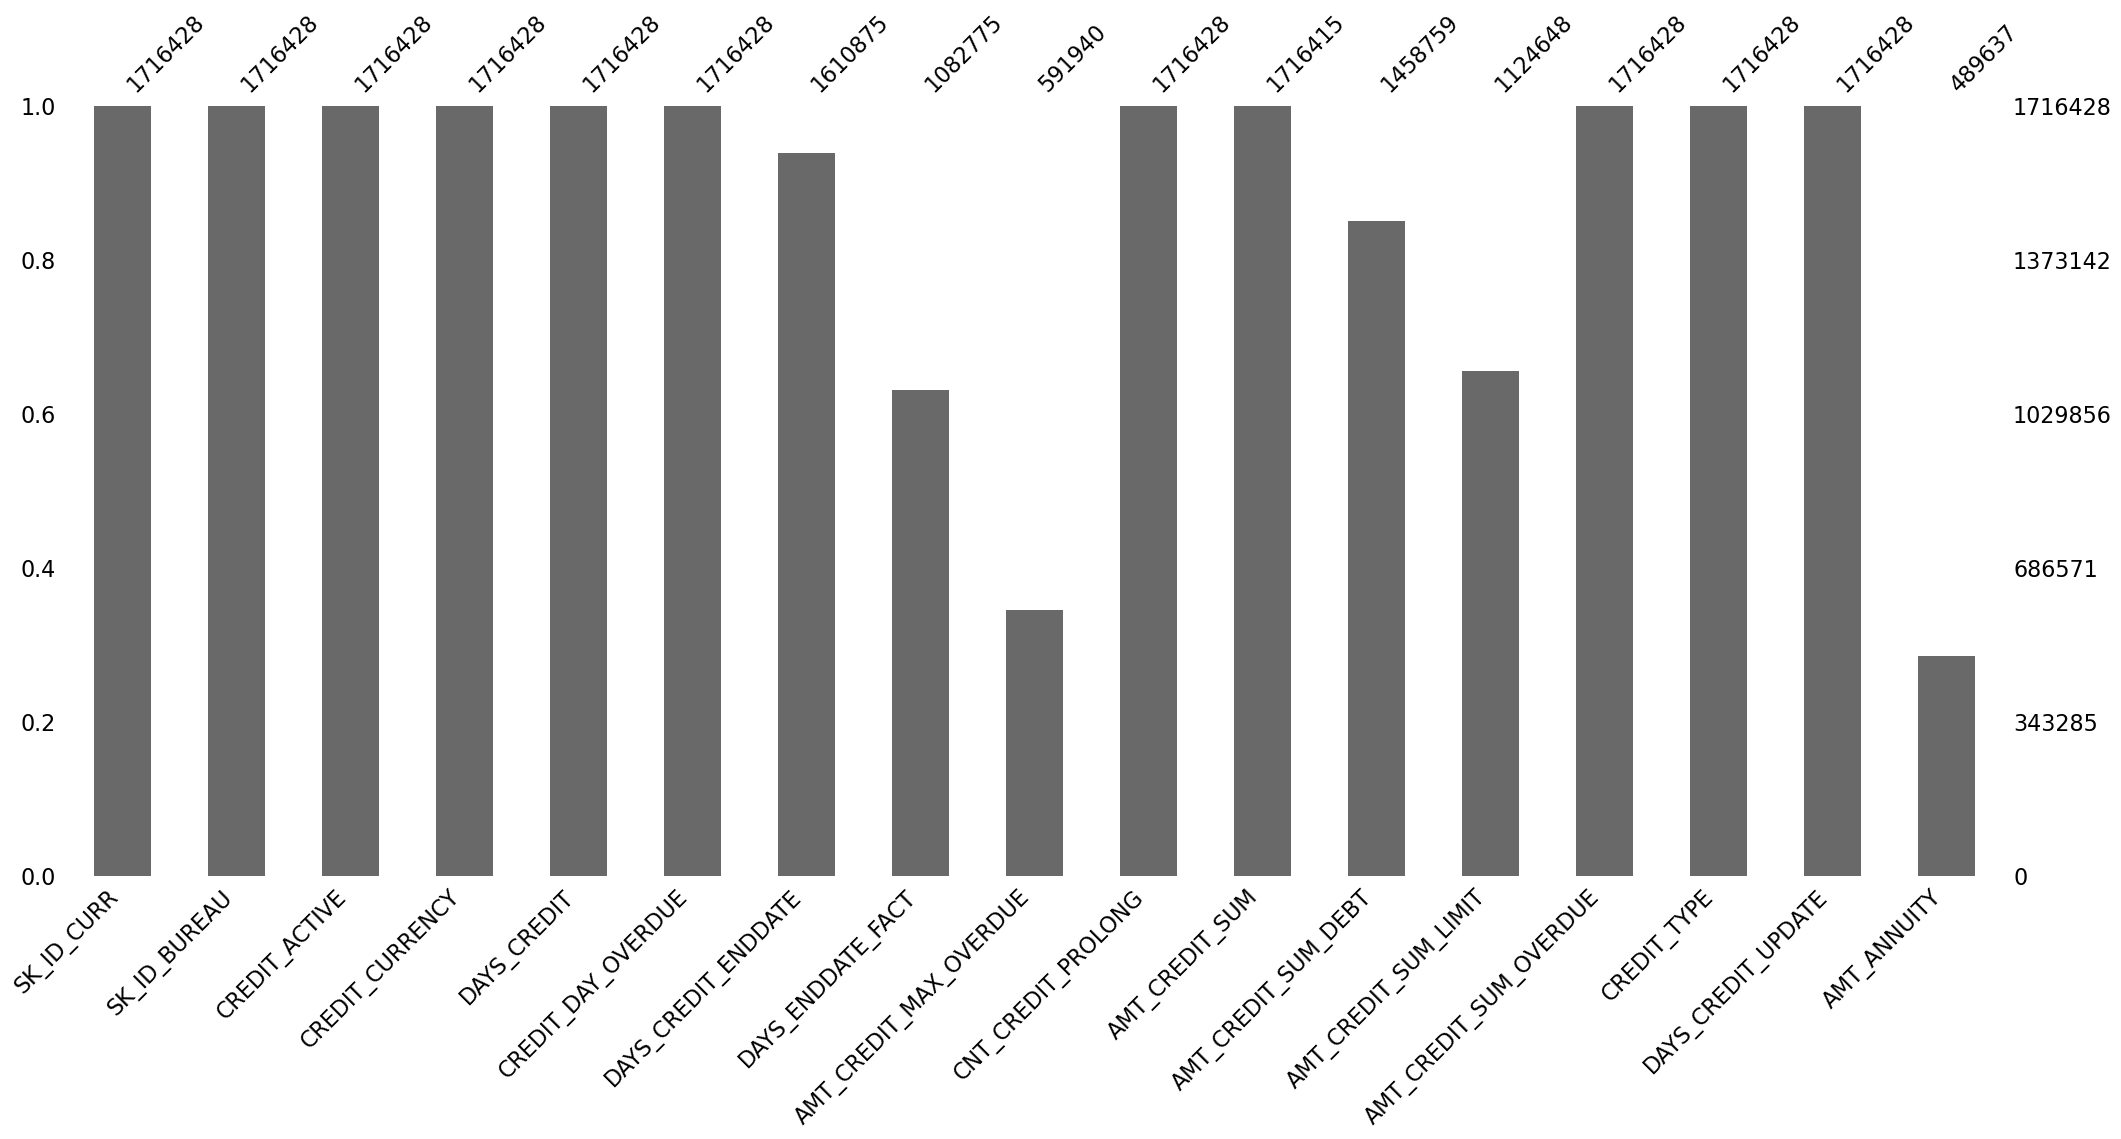

In [80]:
msno.bar(bureau)

Using the above chart we can see that most columns have no missing values and other that the other missing values are only missing around 20% or less. That being said we still have 4 columns that do not fit this same criteria. Generally speaking it is much easier to impute value when there aren't many missing and when it makes sense to do so. For example, imputing AMT_CREDIT_SUM_DEBT is much easier to do because it has few missing values and, as the graph below shows, it is highly correlated with AMT_CREDIT_SUM_LIMIT. Other columns that I might drop though would include AMT_ANNUITY and AMT_CREDIT_MAX_OVERDUE. They are just missing to much information.

<Axes: >

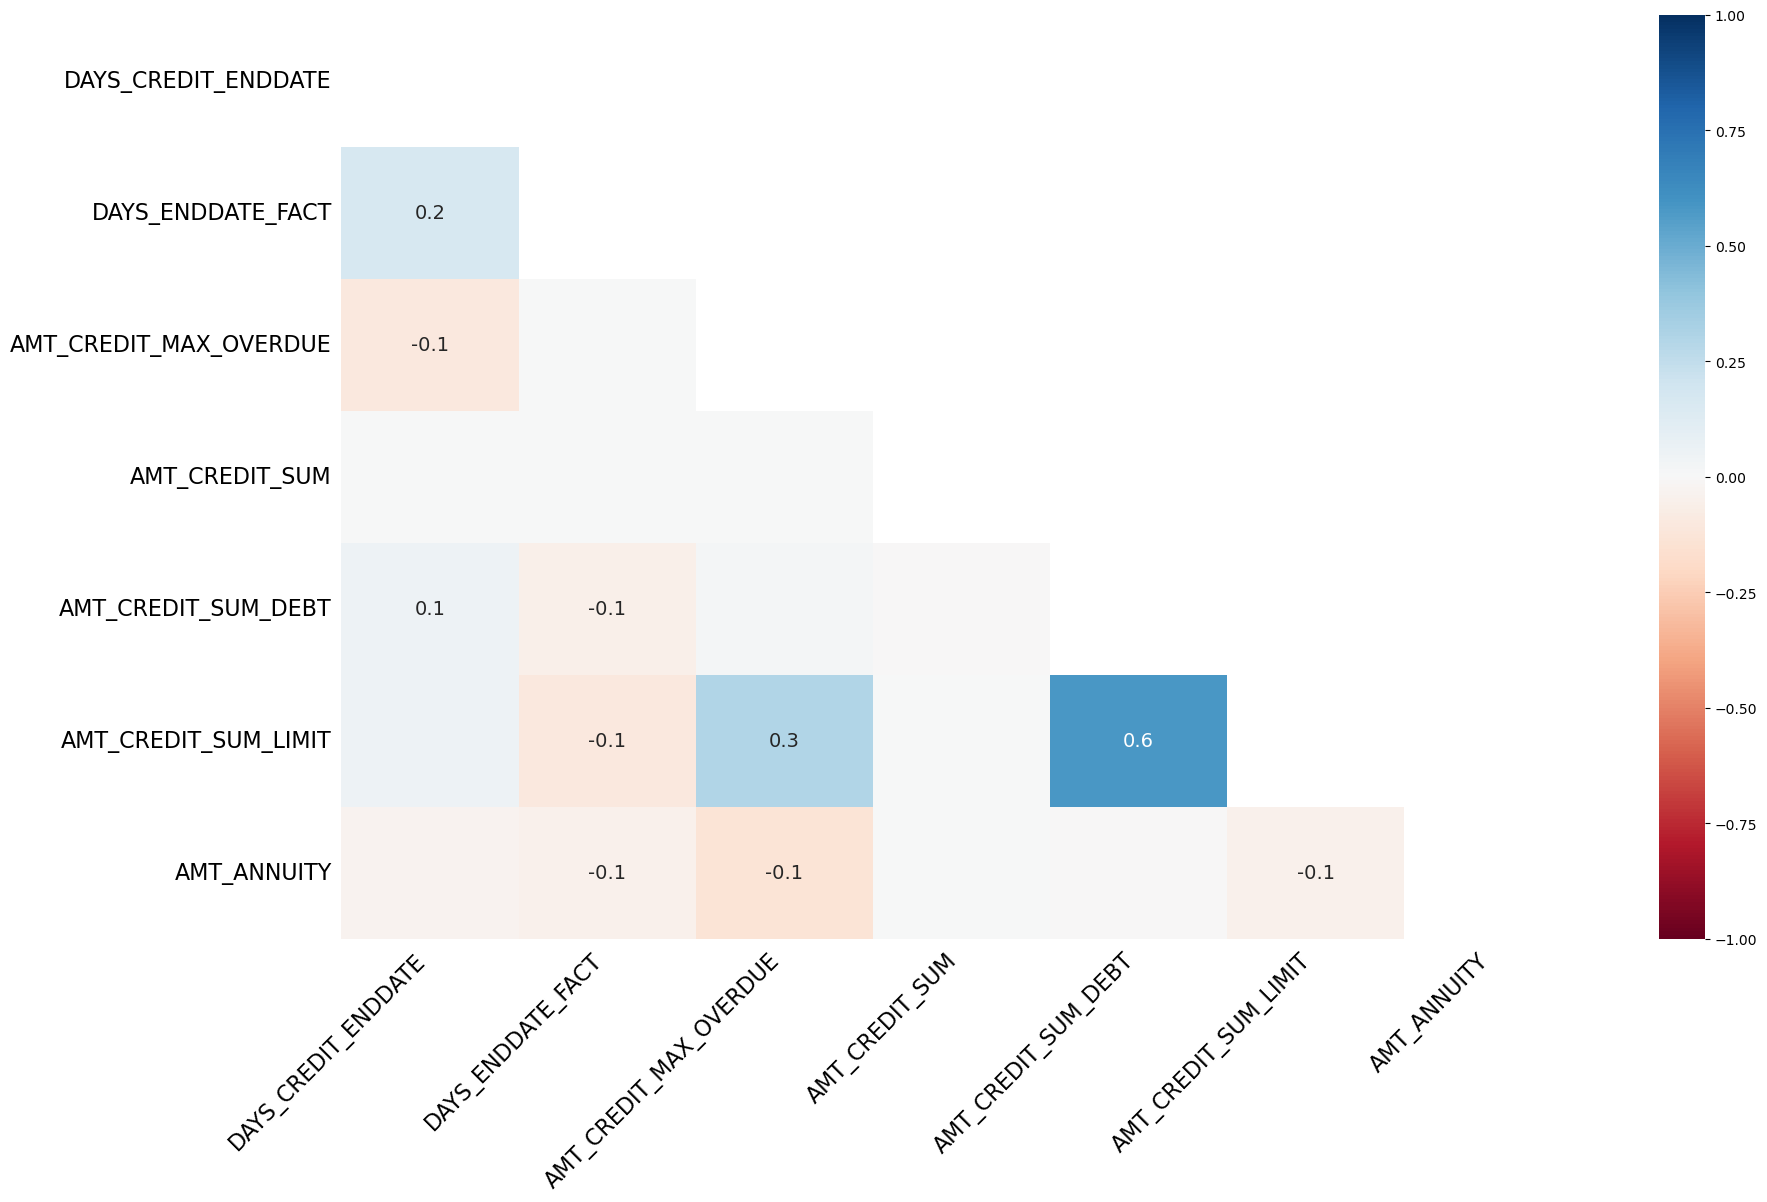

In [81]:
msno.heatmap(bureau)

# Joining Bureau and Test/Train Datasets

In [82]:
#aggregating Bureau
bureau_agg = bureau.groupby('SK_ID_CURR').agg({'DAYS_CREDIT': 'mean', 'CREDIT_DAY_OVERDUE': 'mean', 'CNT_CREDIT_PROLONG' : 'mean', 
                                               'AMT_CREDIT_SUM' : 'mean','AMT_CREDIT_SUM_DEBT' : 'mean','AMT_CREDIT_SUM_OVERDUE' : 'mean'})
pd.DataFrame(bureau_agg)
bureau_agg = bureau_agg.rename(columns={'DAYS_CREDIT':'AVG_DAYS_CREDIT', 'CREDIT_DAY_OVERDUE':'AVG_CREDIT_DAY_OVERDUE','CNT_CREDIT_PROLONG' :'AVG_CNT_CREDIT_PROLONG', 
                                        'AMT_CREDIT_SUM':'AVG_AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT':'AVG_AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE':'AVG_AMT_CREDIT_SUM_OVERDUE'})

In [83]:
application_train_bureau = pd.merge(application_train, bureau_agg, how='left', on='SK_ID_CURR')

Did adding any of the new columns give us more important features?

In [84]:
#fising cateforical varibles to see what 
label_encoder = LabelEncoder()
application_train_bureau['NAME_EDUCATION_TYPE'] = label_encoder.fit_transform(application_train_bureau['NAME_EDUCATION_TYPE'])
application_train_bureau['WEEKDAY_APPR_PROCESS_START'] = label_encoder.fit_transform(application_train_bureau['WEEKDAY_APPR_PROCESS_START']) 
df_encoded = pd.get_dummies(application_train_bureau, columns=['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',
                                                        'NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','OCCUPATION_TYPE',
                                                        'ORGANIZATION_TYPE','FONDKAPREMONT_MODE','HOUSETYPE_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE'], drop_first=True)
len(df_encoded.columns)


model = RandomForestClassifier()
X = df_encoded.drop('TARGET', axis=1)
y = df_encoded['TARGET']
model.fit(X, y)

importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(25))

                        Feature  Importance
31                 EXT_SOURCE_2    0.047210
32                 EXT_SOURCE_3    0.042852
8                    DAYS_BIRTH    0.029915
11              DAYS_ID_PUBLISH    0.029202
10            DAYS_REGISTRATION    0.029181
107             AVG_DAYS_CREDIT    0.028865
0                    SK_ID_CURR    0.028031
4                   AMT_ANNUITY    0.026538
9                 DAYS_EMPLOYED    0.025717
80       DAYS_LAST_PHONE_CHANGE    0.025640
3                    AMT_CREDIT    0.025242
30                 EXT_SOURCE_1    0.024772
110          AVG_AMT_CREDIT_SUM    0.024689
111     AVG_AMT_CREDIT_SUM_DEBT    0.022861
2              AMT_INCOME_TOTAL    0.022720
5               AMT_GOODS_PRICE    0.022248
7    REGION_POPULATION_RELATIVE    0.021952
23      HOUR_APPR_PROCESS_START    0.020006
22   WEEKDAY_APPR_PROCESS_START    0.014184
106  AMT_REQ_CREDIT_BUREAU_YEAR    0.013629
12                  OWN_CAR_AGE    0.012429
78     OBS_60_CNT_SOCIAL_CIRCLE 

If looking at our new list of important fields we can see a number of them came from our attached dataset. For example the AVG_DAYS_CREDIT is the 6th most important feature as calcualted by our random forest classifier. This field came from the Bureau dataset. I didn't add all the columns from that dataset so it will be good to dive deeper into it after fising some of the missing values and see what other important features we can extract.

Overall I feel like I have much better understanding our what weakness our dataset has as far as missing values and what features I should look deeper into or fix so that it can contribute to the model. Other aspects of the data I would like to look into in the future are the exact impute methods I would use to fix missing values. Additionally, I would like to bring in more columns from the beurau dataset and see if they add any significance to our target. Overall though, I am looking forward to seeing if we have enouigh data to beat 92% percent preditor. I think this will be quite the challenge.